# 09 · PAGA

[Chapter 08](08_cell_type_annotation.ipynb) gave you three named states. It did not give
you any relationship *between* them — a clustering returns groups, and a group has no
neighbours.

But the neighbour graph knows. Two clusters joined by thousands of edges are adjacent in
the data; two joined by none are not, whatever a UMAP puts next to what. **PAGA** —
partition-based graph abstraction — collapses the cell-level graph into a graph *between
clusters*, so that the connectivity you already computed becomes something you can read.

| | |
|---|---|
| **1** | Cluster finer than you want to name |
| **2** | Abstract the graph |
| **3** | Read an edge honestly |
| **4** | What the topology says |
| **5** | Use it to lay out a UMAP |

:::{note}
Still the controls — every DMSO and PBS cell, no compounds. Whatever shape appears here is
the shape untreated cells make on their own, which is the only baseline against which a
perturbation means anything.
:::

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

plt.rcParams.update({          # the house style, no package needed
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False,
    "legend.frameon": False, "pdf.fonttype": 42, "ps.fonttype": 42,
})
pd.set_option("display.width", 140)

# The tables live here on Euler. Change this line if your copy is elsewhere.
DATA = Path("/cluster/project/mcsliberali/data_mcs_2026")

cells = sc.read_h5ad(DATA / "mcs2026_controls_downstream.h5ad")
identity = [m for m in cells.uns["panels"]["identity"] if m in set(cells.var_names)]

print(f"{cells.n_obs:,} control cells")
print(f"  states from chapter 08: {list(cells.obs.cell_state.cat.categories)}")
print(f"  graph : {cells.obsp['connectivities'].nnz:,} edges, from chapter 07")

97,177 control cells
  states from chapter 08: ['Pluripotent', 'TE-like', 'Hypoblast', 'artefact']
  graph : 1,885,118 edges, from chapter 07


## 1 · Cluster finer than you want to name

Chapter 08 settled on resolution 0.1 because three clusters were all it could **name**.
That is the right resolution for an annotation and the wrong one for a topology: three
blobs have three possible edges, and a graph with three nodes tells you almost nothing.

PAGA wants more nodes than you would ever put in a figure legend. The abstraction is what
makes them readable again.

In [2]:
for resolution in [0.1, 0.3]:
    sc.tl.leiden(cells, resolution=resolution, key_added=f"leiden_{resolution}",
                 flavor="igraph", n_iterations=2, random_state=0)
    counts = cells.obs[f"leiden_{resolution}"].value_counts()
    print(f"  resolution {resolution}: {len(counts):2d} clusters, "
          f"smallest {counts.min():,} cells ({counts.min() / cells.n_obs:.2%})")

cells.obs["fine"] = cells.obs["leiden_0.3"]

  resolution 0.1:  5 clusters, smallest 469 cells (0.48%)
  resolution 0.3: 12 clusters, smallest 741 cells (0.76%)


Seven clusters, and the profile is what makes them worth having. Read it before the graph:

In [3]:
profile = (pd.DataFrame(cells.obsm["X_identity"], columns=identity)
           .groupby(cells.obs.fine.astype(str).values, observed=True).mean())
profile.index.name = "cluster"
sizes = cells.obs.fine.value_counts()
profile.round(2).join(sizes.rename("cells"))

,Oct4,Nanog,Sox2,GATA3,GATA6,PDGFRa,GATA4,SOX17,cells
cluster,,,,,,,,,
0,0.32,0.42,0.28,-0.28,-0.25,-0.21,0.01,-0.42,19038
1,-0.61,-0.79,-1.11,0.13,0.01,0.07,0.03,1.17,11937
10,0.57,0.66,0.41,0.12,0.30,3.45,0.03,-0.03,741
11,-0.93,-0.96,-1.43,-1.30,0.12,0.47,3.08,2.13,9601
2,-0.92,-0.80,-1.41,1.98,0.20,0.47,0.19,0.47,7815
3,0.84,0.86,0.63,0.32,0.10,0.77,0.02,0.32,10948
4,1.07,0.96,0.72,0.31,1.03,0.72,0.06,0.07,19167
5,-1.21,-1.17,-1.43,1.19,-0.84,-0.77,0.01,-0.60,9116
6,-1.40,-1.09,-1.21,-1.31,-1.23,-2.34,0.11,-0.49,1525


Most of these are versions of the three named states — several flavours of pluripotent,
one strongly GATA3, one strongly GATA4/SOX17. One of them is not.

In [4]:
both = profile[(profile[["Oct4", "Nanog", "Sox2"]].mean(axis=1) > 0.3)
               & (profile[["GATA4", "SOX17"]].mean(axis=1) > 0.5)]
print(f"clusters high in pluripotency AND hypoblast markers at once: {list(both.index)}")
both.round(2).join(sizes.rename("cells"))

clusters high in pluripotency AND hypoblast markers at once: ['7']


,Oct4,Nanog,Sox2,GATA3,GATA6,PDGFRa,GATA4,SOX17,cells
cluster,,,,,,,,,
7,0.94,0.84,0.59,0.1,0.77,1.12,1.96,1.24,2507


:::{important}
**A cluster that is high in both.** Oct4, Nanog and Sox2 up — and GATA4 and SOX17 up as
well, in the same cells. Under the three-state annotation these were filed as
`Pluripotent`, because that is the closest of three names, and the co-expression was
invisible.

Co-expression of a starting state and a destination state is what a **transition** looks
like in fixed cells. You cannot watch a cell change in a 4i experiment — every cell is
imaged once, dead — so a cell caught carrying both programmes is as close as the data
comes to showing you the act.

It is also a small minority of the cells, which is why the resolution mattered: at 0.1 it
sits inside a larger cluster and there is nothing to see.
:::

## 2 · Abstract the graph

`sc.tl.paga` takes the cell-level neighbour graph and a partition of it, and returns one
weight per pair of clusters: how connected they are, relative to how connected they would
be if edges were placed at random.

In [5]:
sc.tl.paga(cells, groups="fine")

connectivity = pd.DataFrame(cells.uns["paga"]["connectivities"].toarray(),
                            index=profile.index, columns=profile.index)
connectivity.round(3)

cluster,0,1,10,11,2,3,4,5,6,7,8,9
cluster,,,,,,,,,,,,
0,0.000,0.091,0.002,0.186,0.077,0.023,0.045,0.034,0.046,0.081,0.053,0.000
1,0.091,0.000,0.202,0.042,0.039,0.148,0.201,0.016,0.089,0.239,0.122,0.037
10,0.002,0.202,0.000,0.000,0.000,0.289,0.008,0.026,0.263,0.112,0.000,0.022
11,0.186,0.042,0.000,0.000,0.280,0.000,0.000,0.139,0.163,0.023,0.293,0.000
2,0.077,0.039,0.000,0.280,0.000,0.000,0.000,0.126,0.101,0.002,0.095,0.001
3,0.023,0.148,0.289,0.000,0.000,0.000,0.195,0.000,0.047,0.099,0.000,0.000
4,0.045,0.201,0.008,0.000,0.000,0.195,0.000,0.017,0.000,0.263,0.000,0.015
5,0.034,0.016,0.026,0.139,0.126,0.000,0.017,0.000,0.052,0.004,0.106,0.039
6,0.046,0.089,0.263,0.163,0.101,0.047,0.000,0.052,0.000,0.015,0.057,0.000


Drawing it needs a **threshold**, because almost every pair has some connectivity. Section
3 is about choosing one; for now take a value that leaves the graph in one piece, and note
that you had to look at the numbers to find it.

In [6]:
def components(matrix, cut):
    """Which clusters remain connected once edges below `cut` are dropped."""
    nodes, seen, groups = list(matrix.index), set(), []
    for start in nodes:
        if start in seen:
            continue
        stack, group = [start], set()
        while stack:
            node = stack.pop()
            if node in group:
                continue
            group.add(node); seen.add(node)
            stack += [m for m in nodes if m != node and matrix.loc[node, m] > cut]
        groups.append(sorted(group))
    return groups

for cut in [0.05, 0.07, 0.10, 0.15]:
    pieces = components(connectivity, cut)
    edges = int((np.triu(connectivity.values, 1) > cut).sum())
    print(f"  threshold {cut:.2f}: {edges:2d} edges, {len(pieces)} component(s)  {pieces}")

THRESHOLD = 0.07

  threshold 0.05: 28 edges, 2 component(s)  [['0', '1', '10', '11', '2', '3', '4', '5', '6', '7', '8'], ['9']]
  threshold 0.07: 25 edges, 2 component(s)  [['0', '1', '10', '11', '2', '3', '4', '5', '6', '7', '8'], ['9']]
  threshold 0.10: 18 edges, 2 component(s)  [['0', '1', '10', '11', '2', '3', '4', '5', '6', '7', '8'], ['9']]
  threshold 0.15: 11 edges, 3 component(s)  [['0', '1', '10', '11', '2', '3', '4', '6', '7', '8'], ['5'], ['9']]


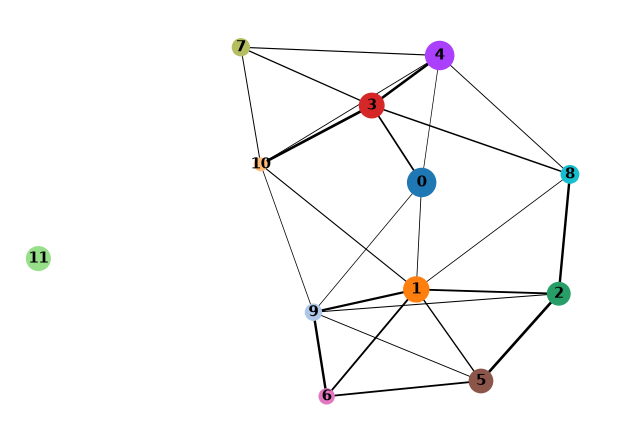

In [7]:
sc.pl.paga(cells, threshold=THRESHOLD, frameon=False, fontsize=10,
           node_size_scale=1.5, edge_width_scale=0.8)

## 3 · Read an edge honestly

The number in that matrix is a **strength**, not a fact. Every pair of clusters gets one,
and almost every one of them is greater than zero.

  66 possible edges
    above 0.00: 53 edges
    above 0.01: 45 edges
    above 0.05: 28 edges
    above 0.07: 25 edges
    above 0.10: 18 edges
    above 0.20:  8 edges


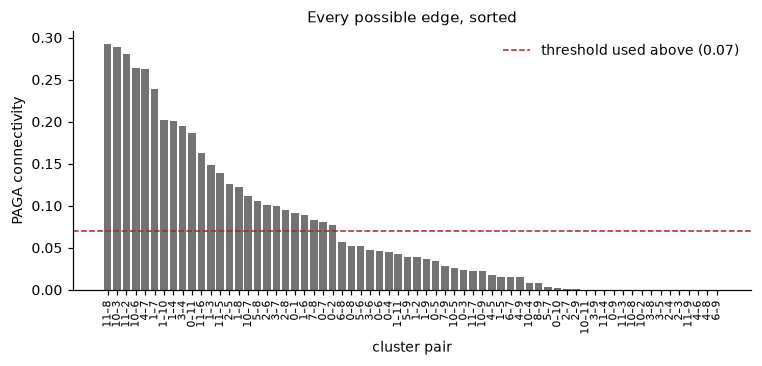

In [8]:
pairs = [(a, b, connectivity.loc[a, b])
         for i, a in enumerate(connectivity.index) for b in connectivity.index[i + 1:]]
weights = pd.Series({f"{a}–{b}": w for a, b, w in pairs}).sort_values(ascending=False)

print(f"  {len(pairs)} possible edges")
for cut in [0.0, 0.01, 0.05, 0.07, 0.10, 0.20]:
    print(f"    above {cut:.2f}: {(weights > cut).sum():2d} edges")

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.bar(range(len(weights)), weights.values, color="0.45")
ax.axhline(THRESHOLD, color="firebrick", ls="--", lw=1, label=f"threshold used above ({THRESHOLD})")
ax.set(xticks=range(len(weights)), xlabel="cluster pair", ylabel="PAGA connectivity",
       title="Every possible edge, sorted")
ax.set_xticklabels(weights.index, rotation=90, fontsize=7)
ax.legend()
fig.tight_layout()

:::{warning}
**The threshold is a choice, and here it is doing more work than anywhere else in the
course.** Drop it to 0.01 and the graph is nearly complete — every state connected to every
other, which is true and useless. Raise it to 0.10 and the component listing above shows
the graph breaking into three pieces, with the hypoblast cluster **alone**.

Look at where its edges actually fall. The two strongest run to the co-expressing cluster
and to the SOX17-high one, and both sit just under 0.10 — so the single most interesting
feature of this graph is also the one closest to the cut. Move the threshold by two
hundredths and the route into hypoblast appears or vanishes.

There is no correct value. What is required is that you **say which one you used**, and
that the claim survives a reasonable change to it. This one does not survive 0.10, so the
honest report is the range: the route is present below about 0.08 and gone above it.

The bar chart is the honest version of the picture: it shows there is no gap in the
distribution to cut at, which is exactly the thing a thresholded network diagram hides.
:::

## 4 · What the topology says

Now read the graph against the profiles. Order the clusters by how pluripotent they are
and ask which ones the strong edges join.

In [9]:
summary = pd.DataFrame({
    "cells": sizes,
    "pluripotency": profile[["Oct4", "Nanog", "Sox2"]].mean(axis=1).round(2),
    "hypoblast": profile[["GATA4", "SOX17"]].mean(axis=1).round(2),
    "GATA3": profile["GATA3"].round(2),
    "state (ch 08)": (pd.crosstab(cells.obs.fine, cells.obs.cell_state)
                      .idxmax(axis=1)),
})
strong = {a: [] for a in connectivity.index}
for a, b, w in pairs:
    if w > THRESHOLD:
        strong[a].append(f"{b} ({w:.2f})"); strong[b].append(f"{a} ({w:.2f})")
summary["joined to"] = pd.Series({k: ", ".join(v) for k, v in strong.items()})
summary.sort_values("pluripotency", ascending=False)

,cells,pluripotency,hypoblast,GATA3,state (ch 08),joined to
4,19167,0.92,0.06,0.31,Pluripotent,"1 (0.20), 3 (0.20), 7 (0.26)"
7,2507,0.79,1.60,0.10,Pluripotent,"0 (0.08), 1 (0.24), 10 (0.11), 3 (0.10), 4 (0...."
3,10948,0.77,0.17,0.32,Pluripotent,"1 (0.15), 10 (0.29), 4 (0.20), 7 (0.10)"
10,741,0.54,0.00,0.12,Pluripotent,"1 (0.20), 3 (0.29), 6 (0.26), 7 (0.11)"
0,19038,0.34,-0.20,-0.28,Pluripotent,"1 (0.09), 11 (0.19), 2 (0.08), 7 (0.08)"
8,2805,0.32,0.06,1.84,Pluripotent,"1 (0.12), 11 (0.29), 2 (0.09), 5 (0.11), 7 (0.08)"
9,1977,-0.36,0.22,0.41,TE-like,
1,11937,-0.84,0.60,0.13,TE-like,"0 (0.09), 10 (0.20), 3 (0.15), 4 (0.20), 6 (0...."
2,7815,-1.04,0.33,1.98,TE-like,"0 (0.08), 11 (0.28), 5 (0.13), 6 (0.10), 8 (0.09)"
11,9601,-1.11,2.61,-1.30,Hypoblast,"0 (0.19), 2 (0.28), 5 (0.14), 6 (0.16), 8 (0.29)"


Read the `joined to` column down the table, in order of pluripotency. Pluripotency sits at
the top and falls away along two different routes, and the ends of those routes are the two
differentiated states:

```text
                         ┌──  GATA3-high (trophectoderm-like)
  pluripotent core  ─────┤
                         └──  co-expressing  ──┐
                                               ├──  hypoblast
                            SOX17-high  ───────┘
```

The **co-expressing cluster** is the one to stop on. It carries pluripotency *and* GATA4,
SOX17 and PDGFRa at once, it sits between the pluripotent core and the hypoblast cluster,
and it is a few per cent of the cells. Under the three-state annotation of
[chapter 08](08_cell_type_annotation.ipynb) it was filed as `Pluripotent` — the nearest of
three names — and the co-expression was invisible.

Co-expression of a starting state and a destination state is what a **transition** looks
like in fixed cells. You cannot watch a cell change in a 4i experiment — every cell is
imaged once, dead — so a cell caught carrying both programmes is as close as the data comes
to showing you the act.

:::{caution}
**A path is not a trajectory.** PAGA reports which clusters are adjacent in the data, not
which turns into which, and it has no notion of direction at all. Every arrow you might
want to draw on this picture comes from somewhere else — the timepoints, below, or the
biology you brought with you.
:::

### The timepoints are the check

The graph was built from marker levels alone and never saw the clock. If its shape is
real, the clusters it puts at the far end should be the ones that fill up late.

In [10]:
composition = pd.crosstab(cells.obs.fine, cells.obs.timepoint_h.astype(int),
                          normalize="index").mul(100).round(1)
composition.join(summary[["cells", "state (ch 08)"]])

,36,48,60,84,cells,state (ch 08)
fine,,,,,,
0,25.7,23.0,22.1,29.2,19038,Pluripotent
1,18.5,32.8,34.6,14.1,11937,TE-like
2,0.4,5.9,38.0,55.7,7815,TE-like
3,9.3,13.6,36.0,41.1,10948,Pluripotent
4,5.4,13.4,24.4,56.8,19167,Pluripotent
5,5.8,13.5,34.1,46.5,9116,TE-like
6,25.6,25.4,19.9,29.1,1525,TE-like
7,1.8,3.1,15.5,79.7,2507,Pluripotent
8,0.7,3.5,27.4,68.4,2805,Pluripotent


The hypoblast cluster is overwhelmingly a late one — a few tenths of a percent of it comes
from 36 hours, three quarters from 84. Nothing told PAGA that. It also holds for the
co-expressing cluster, which is likewise late-shifted, as a state on the way to hypoblast
has to be.

:::{tip}
**This is the shape to remember, because Part 4 measures against it.** Untreated cells
leave the pluripotent core along more than one route, and one of those routes passes
through a small population carrying both programmes at once.

A compound can change that picture in ways an abundance measurement would miss entirely:
it can empty the bridge while leaving both endpoints intact, or cut one route and leave
the other. Counting how many cells are in each state cannot tell those apart. The topology
can, and [Part 4](../../part4_final_solutions/intro.md) asks it to.
:::

## 5 · Use it to lay out a UMAP

A UMAP starts from a random initialisation, which is why chapter 07's two runs came out
rearranged. Starting it from the PAGA layout instead makes the global arrangement
reproducible and roughly meaningful, because it inherits a structure that *was* computed
from connectivity.

/cluster/home/maaraujo/venvs/mcs2026/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


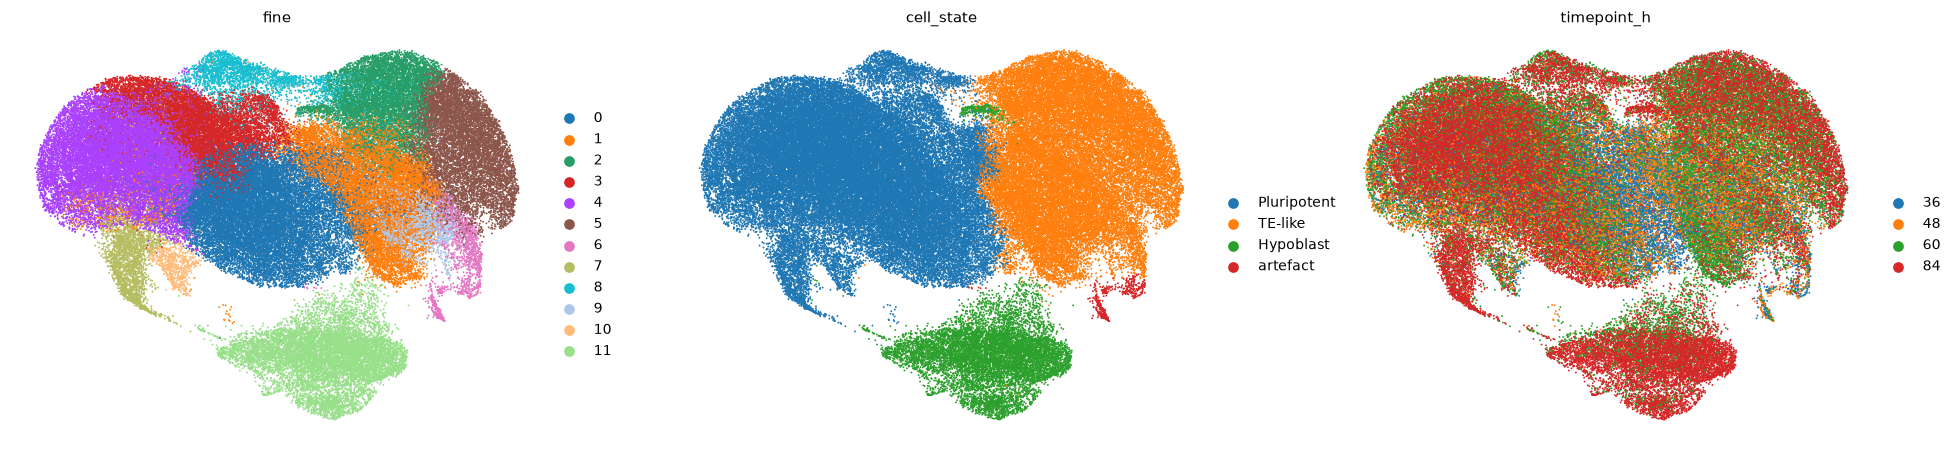

In [11]:
sc.tl.paga(cells, groups="fine")          # on the 38-marker graph, which the UMAP uses
sc.pl.paga(cells, plot=False)             # computes uns['paga']['pos'] -- required below
sc.tl.umap(cells, init_pos="paga", random_state=0)

sc.pl.umap(cells, color=["fine", "cell_state", "timepoint_h"],
           ncols=3, s=6, frameon=False)

In [ ]:
sc.tl.draw_graph(cells, init_pos="paga")

:::{note}
**`sc.pl.paga` must run before `sc.tl.umap(init_pos="paga")`.** The layout positions are
computed by the *plotting* function, not the tool, and scanpy will otherwise stop with
`Plot PAGA first, so that adata.uns['paga']['pos'] exists`. Passing `plot=False` computes
them without drawing anything.

This is a real trap and not a deep one: an initialisation is not a result, and a
PAGA-initialised UMAP is no more true than a random one. It is more *reproducible*, which
is a different and smaller virtue.
:::

## Save

In [12]:
cells.write_h5ad(DATA / "mcs2026_controls_downstream.h5ad", compression="gzip")
print(f"  obs : fine ({cells.obs.fine.nunique()} clusters), cell_state")
print(f"  obsm: {list(cells.obsm)}")
print(f"  uns : paga connectivities for {len(connectivity)} clusters")

  obs : fine (12 clusters), cell_state
  obsm: ['X_identity', 'X_pca', 'X_umap']
  uns : paga connectivities for 12 clusters


---

## Exercises

### 1. Does the topology survive the resolution?

Rebuild the PAGA graph at resolutions 0.2, 0.3 and 0.6. Does a cluster co-expressing
pluripotency and hypoblast markers appear every time? Does it stay on the route between
the two endpoints?

:::{admonition} Solution
:class: dropdown

```python
for resolution in [0.2, 0.3, 0.6]:
    key = f"r{resolution}"
    sc.tl.leiden(cells, resolution=resolution, key_added=key,
                 flavor="igraph", n_iterations=2, random_state=0)
    prof = (pd.DataFrame(cells.obsm["X_identity"], columns=identity)
            .groupby(cells.obs[key].astype(str).values, observed=True).mean())
    mixed = prof[(prof[["Oct4", "Nanog", "Sox2"]].mean(axis=1) > 0.3)
                 & (prof[["GATA4", "SOX17"]].mean(axis=1) > 0.5)]
    print(f"{resolution}: {len(prof)} clusters, {len(mixed)} co-expressing")
```

A structure that appears at one resolution and nowhere else is a property of the
clustering. One that appears across a range — sometimes split into two clusters, sometimes
merged — is a property of the data, and that is what you report, with the range.
:::

### 2. Rebuild it on a panel that should not work

The graph so far uses eight lineage markers. Build the neighbour graph and the PAGA on the
**organelle** panel instead. Do you still get a route between pluripotent and hypoblast?
Should you?

:::{admonition} Solution
:class: dropdown

```python
organelles = [m for m in cells.uns["panels"]["organelles"] if m in set(cells.var_names)]
cells.obsm["X_organelles"] = np.asarray(cells[:, organelles].X)
sc.pp.neighbors(cells, n_neighbors=15, use_rep="X_organelles",
                key_added="org", random_state=0)
sc.tl.leiden(cells, resolution=0.3, key_added="org_fine", neighbors_key="org",
             flavor="igraph", n_iterations=2, random_state=0)
sc.tl.paga(cells, groups="org_fine", neighbors_key="org")
print(pd.crosstab(cells.obs.org_fine, cells.obs.cell_state, normalize="index").round(2))
```

You will still get clusters and still get a connected graph, because PAGA always returns
one. The question is whether the clusters correspond to anything: cross-tabulate them
against `cell_state` and see whether organelle markers separate lineages at all.

The lesson is the one from chapter 09's third section in a different form. The method does
not check whether your features answer your question — only you can do that, and the
cross-tabulation is how.
:::

### 3. Move a threshold until the story changes

Find the value at which the hypoblast cluster detaches from the rest of the graph. How far
is it from the one this chapter used?

:::{admonition} Solution
:class: dropdown

```python
for cut in [0.05, 0.08, 0.10, 0.15, 0.20, 0.25]:
    kept = [(a, b) for a, b, w in pairs if w > cut]
    print(f"threshold {cut:.2f}: {len(kept):2d} edges")
```

Then draw two of them and see which claims survive.

The point of the exercise is to make the fragility concrete before you rely on it. If your
conclusion needs the threshold to be 0.07 rather than 0.09, the conclusion is about the
threshold. Report the range over which it holds, or find a claim that does not need one —
an edge weight is a number and can be compared between conditions without being cut at
all, which is what Part 4 does.
:::

---

**Next:** [10 · Diffusion maps](10_diffusion_map.ipynb).